# Brownian motion

Een van de bekendste voorbeelden van botsende deeltjes in de natuur is Brownian motion.
Fijn gemalen pollen in water lijken te dansen in willekeurige richting.
Dit komt doordat de pollen worden geraakt door watermoleculen die in alle richtingen bewegen.
Omdat de pollen veel zwaarder zijn dan watermoleculen, dus de beweging van de pollen is veel langzamer en minder "intens" dan die van de watermoleculen.
Dit proces van willekeurige beweging door botsingen met kleinere deeltjes wordt Brownian motion genoemd en kunnen we simuleren op basis van ons (premature) botsingsmodel.
Daarbij kunnen we ook gebruik maken van de zojuist geleerde manier van tracking van deeltjes, waarbij we een zowel het zware bolletjes als een enkel deeltje kunnen volgen.

Let op!
We bestuderen hier nog geen thermische effecten, deze opdrachten zijn met name bedoeld om beter te begrijpen hoe het botsingsmodel in elkaar zit.

```{warning}
In dit notebook zitten delen waar ruimte is om code toe te voegen, maar waarbij je denkt... waarom dan?
In een latere opdracht moet je terug naar die cell en de juiste code toevoegen.
```

In [29]:
import numpy as np
import matplotlib.pyplot as plt

In [30]:
# Maken van de ParticleClass

class ParticleClass:
    # Het maken van het deeltje
    def __init__(self, m, v, r, R, c):
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = np.array(R, dtype=float)  
        self.c = c

    # Het updaten van de positie, eventueel met zwaartekracht (extern geregeld)
    def update_position(self):
        # positie updaten aan de hand van huidige snelheid
        self.r += self.v * dt
              
    # Harde wand: nu ondersteuning voor rechthoekige box via globale Box_length_x, Box_length_y
    def boxcollision(self):
        # horizontale wand
        if abs(self.r[0]) + self.R > Box_length_x: 
            self.v[0] = -self.v[0]                                  # Omdraaien van de snelheid
            self.r[0] = np.sign(self.r[0]) * (Box_length_x - self.R)  # Zet terug net binnen box                 
        # verticale wand
        if abs(self.r[1]) + self.R > Box_length_y: 
            self.v[1] = -self.v[1]     
            self.r[1] = np.sign(self.r[1]) * (Box_length_y - self.R) 
            
    @property
    def momentum(self):
        return self.m * self.v
    
    @property
    def kin_energy(self):
        return 1/2 * self.m * np.dot(self.v, self.v)

In [31]:
# Aanmaken van de randvoorwaarden en initiele condities
Box_size_0 = 10
Box_length_0 = Box_size_0/2
Box_length_x = Box_length_0
Box_length_y = Box_length_0     # de hoogte kan later aangepast voor experimenten

# Particles
dt = 0.04
particles = []
N = 40
v_0 = 1

# Aanmaken van deeltjes: N-1 lichte deeltjes en 1 zwaar deeltje in het midden
for i in range(N-1):
    # willekeurige richting met magnitude v_0
    theta = np.random.uniform(0, 2*np.pi)
    vx = v_0 * np.cos(theta)
    vy = v_0 * np.sin(theta)
    pos = np.random.uniform(-Box_length_0, Box_length_0, 2)
    particles.append(ParticleClass(m=1.0, v=[vx, vy], r = pos, R=.5,c='blue')) 

particles.append(ParticleClass(m=20.0, v=[0, 0], r = [0, 0], R=.5,c='red')) 

```{exercise} Brownian motion
:label: ex-brownian-1

Leg uit wat er in de laatste regel van bovenstaande script gebeurt.
Voeg voor deze regel goede metadata toe.
```

Antwoord: De laatste regel voegt een zwaar deeltje toe in het midden van de box (massa 20), met initiële snelheid nul en kleur rood. Dit wordt gebruikt om het effect van vele lichte botsingen op één groot (zwaar) deeltje te bestuderen.

Er is een doos vol met deeltjes op willekeurige positie aangemaakt.
We willen kijken waar de deeltjes zijn terechtgekomen.
Hieronder staat dit weergegeven. 

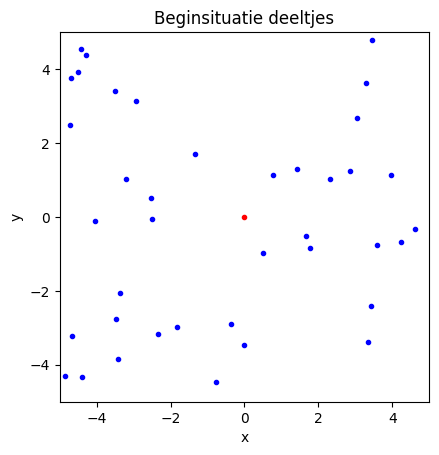

In [32]:
# Inspecteren van beginsituatie
plt.figure()

plt.xlabel('x')
plt.ylabel('y')

plt.xlim(-Box_length_x,Box_length_x)
plt.ylim(-Box_length_y,Box_length_y)

for particle_object in particles:
    plt.plot(particle_object.r[0],particle_object.r[1],color=particle_object.c,marker='.')
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Beginsituatie deeltjes')
plt.show()

```{exercise} 
:label: ex-brownian-2

Er staat ook code met comments ervoor, wat doet deze code? 
Check je antwoord door de comments weg te halen.
Hoe wordt er voor gezorgd dat de snelheid van elk deeltje gelijk is?
```

Antwoord: De code genereert snelheden met dezelfde grote v_0 maar in willekeurige richtingen; daardoor hebben alle lichte deeltjes dezelfde snelheid (gelijk aan v_0) maar verschillende richtingen.

De snelheid blijft gelijk door de snelheid in tegengestelde richting met dezelfde grote terug te kaatsen in de code


In [33]:
# Het bepalen of er een botsing plaats vindt
def collide_detection(p1, p2):
    dx = p1.r[0] - p2.r[0]
    dy = p1.r[1] - p2.r[1]
    rr = p1.R + p2.R
    return dx**2 + dy**2 < rr**2
        
def particle_collision(p1: ParticleClass, p2: ParticleClass):
    """ past snelheden aan uitgaande van overlap. Retourneert True als velocities aangepast zijn."""
    m1, m2 = p1.m, p2.m
    delta_r = p1.r - p2.r
    delta_v = p1.v - p2.v
    dot_product = np.dot(delta_r, delta_v)
    
    # Als deeltjes van elkaar weg bewegen dan geen botsing
    if dot_product >= 0: # '='-teken voorkomt ook problemen als delta_r == \vec{0}
        return False
    
    distance_squared = np.dot(delta_r, delta_r)
    if distance_squared == 0:
        return False
    # Botsing oplossen volgens elastische botsing in 2D (projectie langs delta_r)
    p1.v -= 2 * m2 / (m1 + m2) * dot_product / distance_squared * delta_r
    p2.v += 2 * m1 / (m1 + m2) * dot_product / distance_squared * delta_r
    return True

def handle_collisions(particles):
    """ alle onderlinge botsingen afhandelen voor deeltjes in lijst, retourneert aantal botsingen deze stap """
    num_particles = len(particles)
    collisions = 0
    for i in range(num_particles):
        for j in range(i+1, num_particles):
            if collide_detection(particles[i], particles[j]):
                if particle_collision(particles[i], particles[j]):
                    collisions += 1
    return collisions

In onderstaande code geven we de code voor de simulatie en volgen we de positie van het zware deeltje. 

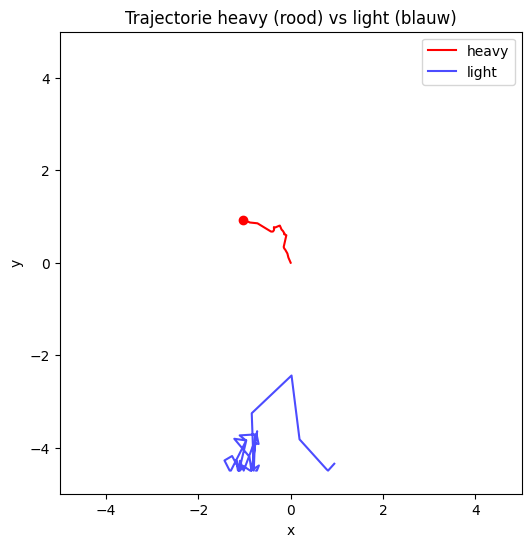

In [34]:
# tracken van het zware deeltje en een licht deeltje
track_x = []
track_y = []
track2_x = []
track2_y = []

# kies één licht deeltje om ook te tracken (kleur blauw)
light_index = 0

# counter voor aantal botsingen per stap
collision_counts = []

num_steps = 400

for i in range(num_steps):
    # update posities en individuele wandbotsingen
    for p in particles:
        p.update_position()    # Update positie        
        p.boxcollision()      # Wandbotsing werkt per deeltje
    
    # onderlinge botsingen afhandelen en tel aantal botsingen
    collisions = handle_collisions(particles)
    collision_counts.append(collisions)

    # track heavy particle (laatste in lijst) en gekozen light particle
    track_x.append(particles[N-1].r[0])
    track_y.append(particles[N-1].r[1])
    track2_x.append(particles[light_index].r[0])
    track2_y.append(particles[light_index].r[1])

plt.figure(figsize=(6,6))
plt.plot(track_x, track_y, 'r-', label='heavy')
plt.plot(track2_x, track2_y, 'b-', alpha=0.7, label='light')
plt.scatter([particles[N-1].r[0]], [particles[N-1].r[1]], color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trajectorie heavy (rood) vs light (blauw)')
plt.legend()
plt.xlim(-Box_length_x, Box_length_x)
plt.ylim(-Box_length_y, Box_length_y)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

```{exercise} Brownian motion in beeld
:label: ex-brownian-3
- Draai de onderstaande simulatie een keer en bestudeer de output.
- Voeg zelf een tweede tracking toe van een licht deeltje en verbeter de plot.
- Wat zijn overeenkomsten en verschillen tussen de beweging van de twee deeltjes?
- Wat valt je op als je de simulatie een aantal keer runt?
```

Antwoord kort: De lichte deeltjes bewegen sneller en nemen grotere trajectbogen; het zware deeltje beweegt veel langzamer en verandert langzamer van richting. Bij meerdere runs verschilt het pad sterk (stochastisch), maar gemiddeld blijft het zware deeltje rond het centrum.

We zouden gevoel willen krijgen voor het aantal botsingen dat per tijdseenheid plaatsvindt. 
Elke keer dat er een botsing plaatsvindt, zou de counter met 1 omhoog moeten gaan.
Idealiter wordt het aantal botsingen opgeslagen in een array zodat je het aantal botsingen als functie van de tijd kunt weergeven.

```{exercise}
Pas bovenstaand idee toe in de eerder gemaakte code.
Plot hieronder het aantal botsingen als functie van de tijd.
```

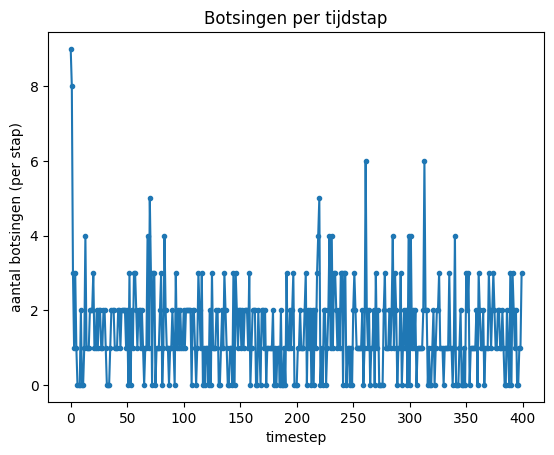

In [35]:
# Plot aantal botsingen per tijdstap
plt.figure()
plt.plot(range(len(collision_counts)), collision_counts, '-o', markersize=3)
plt.xlabel('timestep')
plt.ylabel('aantal botsingen (per stap)')
plt.title('Botsingen per tijdstap')
plt.show()

```{warning} 🌶 Let op!
:icon: false
De onderstaande opdrachten vallen buiten de stof maar tellen mee als je excellent wilt behalen.
```

In zulke fysica modellen is de afgelegde weg (afstand tussen begin en eindpunt) van belang.
Deze afgelegde weg zegt iets over de snelheid van difussie.
Idealiter bekijken we een histogram.
Maar voor een histogram hebben we veel deeltjes nodig.



```{exercise} Afgelegde weg 🌶
:label: ex-brownian-4

- Maak een simulatie met 361 deeltjes, waarvan 1 zwaar deeltje.
- Houd rekening met de boxgrootte, deze moet mee schalen!
- Maak een histogram van de afgelegde weg voor alle deeltjes. 
- Geef de afgelegde weg van het grote deeltje duidelijk aan.
```

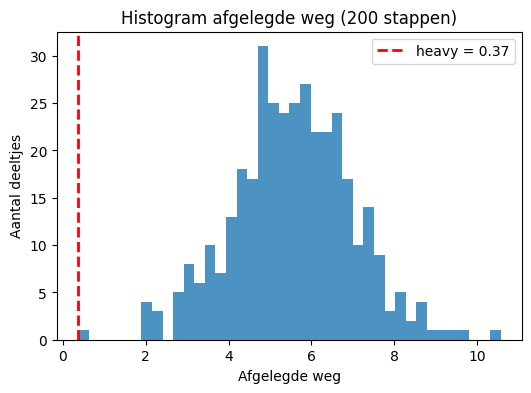

In [36]:
# Simulatie voor 361 deeltjes en histogram van afgelegde weg
N_big = 361
Box_size_big = Box_size_0 * np.sqrt(N_big / N)  # scale box area with particle count
Box_length_big = Box_size_big / 2
Box_length_x_old = Box_length_x; Box_length_y_old = Box_length_y
Box_length_x = Box_length_big
Box_length_y = Box_length_big

dt_saved = dt
dt = 0.04

particles_big = []
for i in range(N_big-1):
    theta = np.random.uniform(0, 2*np.pi)
    vmag = np.random.uniform(0.5, 1.0)
    vx = vmag * np.cos(theta)
    vy = vmag * np.sin(theta)
    pos = np.random.uniform(-Box_length_big, Box_length_big, 2)
    particles_big.append(ParticleClass(m=1.0, v=[vx, vy], r = pos, R=.3,c='blue')) 
particles_big.append(ParticleClass(m=20.0, v=[0, 0], r = [0, 0], R=.5,c='red')) 

steps_big = 200
prev_positions = np.array([p.r.copy() for p in particles_big])
distances = np.zeros(len(particles_big))

for t in range(steps_big):
    for p in particles_big:
        p.update_position()
        p.boxcollision()
    handle_collisions(particles_big)
    # accumulate distances
    for idx, p in enumerate(particles_big):
        distances[idx] += np.linalg.norm(p.r - prev_positions[idx])
        prev_positions[idx] = p.r.copy()

plt.figure(figsize=(6,4))
plt.hist(distances, bins=40, color='C0', alpha=0.8)
heavy_dist = distances[-1]
plt.axvline(heavy_dist, color='red', linestyle='--', linewidth=2, label=f'heavy = {heavy_dist:.2f}')
plt.xlabel('Afgelegde weg')
plt.ylabel('Aantal deeltjes')
plt.title('Histogram afgelegde weg ({} stappen)'.format(steps_big))
plt.legend()
plt.show()

# herstel globale box en dt
Box_length_x = Box_length_x_old
Box_length_y = Box_length_y_old
dt = dt_saved

En nu we toch bezig zijn met twee verschillende deeltjes.... 

We kunnen twee "groepen" van deeltjes aanmaken, elk  met een andere massa. Als we dan de zwaartekracht aan zetten, dan zouden we verwachten dat de lichtere deeltjes boven komen "drijven".

```{exercise} Onderzoek dit vermoeden 🌶
- maak daartoe de box 2x zo hoog als breed
- verdubbel het totaal aantal deeltjes
- zet een artificieel grote zwaartekracht aan
```

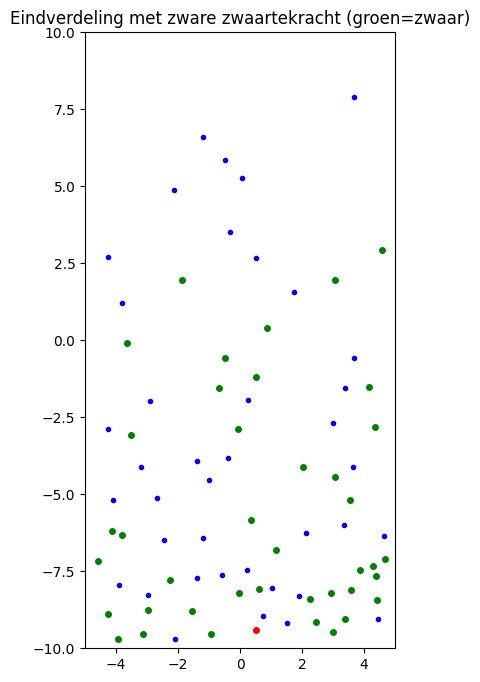

In [37]:
# Gravity segregation experiment
Box_length_x = Box_length_0
Box_length_y = Box_length_0 * 2  # box 2x zo hoog als breed

N_grav = 2 * N  # verdubbel het aantal deeltjes
particles_grav = []

# maak twee groepen: helft licht (m=1), helft zwaar (m=5)
for i in range(N_grav-1):
    m = 1.0 if i < (N_grav-1)//2 else 5.0
    theta = np.random.uniform(0, 2*np.pi)
    vmag = np.random.uniform(0.5, 1.0)
    vx = vmag * np.cos(theta)
    vy = vmag * np.sin(theta)
    pos = np.random.uniform([-Box_length_x, -Box_length_y], [Box_length_x, Box_length_y])
    color = 'blue' if m==1.0 else 'green'
    particles_grav.append(ParticleClass(m=m, v=[vx, vy], r = pos, R=.3, c=color))
# voeg zwaar deeltje toe om te tracken
particles_grav.append(ParticleClass(m=20.0, v=[0, 0], r = [0, 0], R=.5,c='red'))

g = -5.0  # artificiële zware zwaartekracht in y-richting
a = np.array([0.0, g])
steps_grav = 300

for t in range(steps_grav):
    for p in particles_grav:
        # update snelheid door versnelling (EULER stap)
        p.v += a * dt
        p.update_position()
        p.boxcollision()
    handle_collisions(particles_grav)

# plot eindverdeling
plt.figure(figsize=(4,8))
for p in particles_grav:
    plt.plot(p.r[0], p.r[1], marker='o', color=p.c, markersize=3 if p.m<5 else 4)
plt.xlim(-Box_length_x, Box_length_x)
plt.ylim(-Box_length_y, Box_length_y)
plt.gca().set_aspect('auto')
plt.title('Eindverdeling met zware zwaartekracht (groen=zwaar)')
plt.show()